Fetching live historical data for RR.L...


/var/folders/ws/6bbtgfld035ght911rvq8hmm0000gn/T/ipykernel_54762/2898388622.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker, period="5y", interval="1d", progress=False)



=== QUANT PORTFOLIO PERFORMANCE ENGINE: RR.L ===
Live Input Price       : GBp 1400.60
Total Simulated Paths  : 10,000

Performance Metric           | Median (50th)   | Bear (5th)   | Bull (95th) 
---------------------------------------------------------------------------
Terminal Stock Price         |        2183.00 |      1106.48 |      4289.48
Annualized Return            |         55.86% |      -21.00% |      206.26%
Sharpe Ratio (Rf=4.5%)       |           1.24 |        -0.61 |         4.90
Sortino Ratio                |           1.84 |        -0.84 |         7.91
Maximum Drawdown             |        -27.09% |      -46.28% |      -16.01%


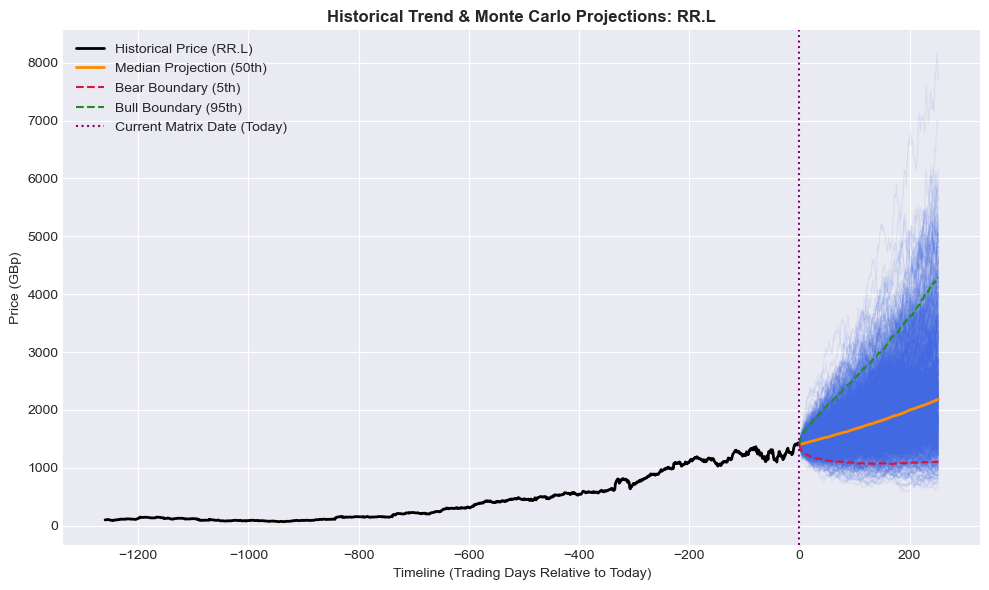

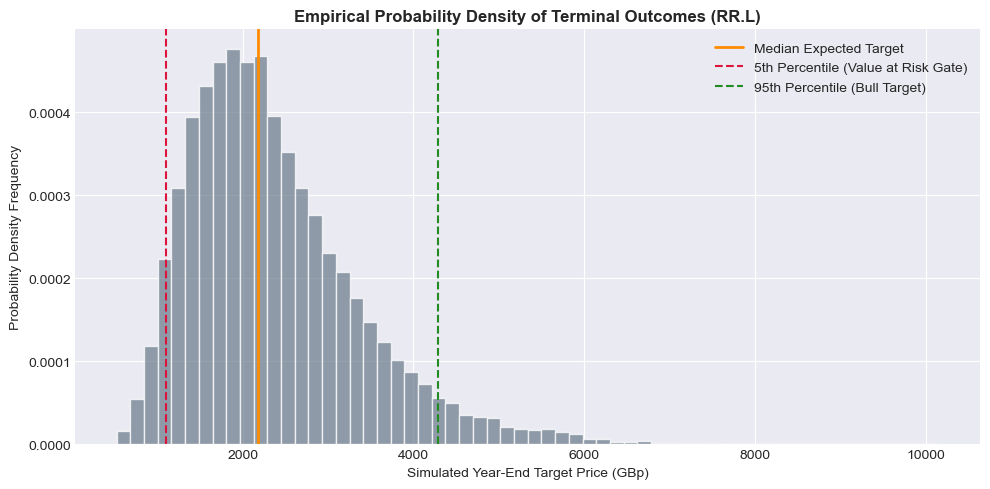

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PULL LIVE MARKET DATA FROM YAHOO FINANCE
# ==============================================================================
ticker = "RR.L"
print(f"Fetching live historical data for {ticker}...")
raw_data = yf.download(ticker, period="5y", interval="1d", progress=False)

# Clean and extract closing price safely from yfinance multi-index format
if isinstance(raw_data.columns, pd.MultiIndex):
    close_prices = raw_data['Close'][ticker].dropna()
else:
    close_prices = raw_data['Close'].dropna()

# ==============================================================================
# 2. EXTRACT REAL-TIME STATISTICAL GROUND TRUTH
# ==============================================================================
# Calculate daily log returns: ln(P_t / P_{t-1})
daily_log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
mean_daily_return = daily_log_returns.mean()
daily_volatility = daily_log_returns.std()

# Baseline Settings
risk_free_rate_annual = 0.045 # 4.5% risk-free rate benchmark (e.g., UK Gilts)
rf_daily = risk_free_rate_annual / 252

# ==============================================================================
# 3. SETUP MONTE CARLO ENGINE
# ==============================================================================
initial_price = float(close_prices.iloc[-1])
time_steps = 252
n_simulations = 10000

np.random.seed(42)
shock_matrix = np.random.normal(0, 1, (time_steps, n_simulations))

# ==============================================================================
# 4. GENERATE PATH RETURNS MATRIX
# ==============================================================================
# Matrix dimension: (252, 10000)
sim_daily_returns = (mean_daily_return - 0.5 * daily_volatility ** 2) + daily_volatility * shock_matrix

# Construct full price trajectories across space and time
cumulative_log_returns = np.vstack([np.zeros(n_simulations), np.cumsum(sim_daily_returns, axis=0)])
price_paths = initial_price * np.exp(cumulative_log_returns)

# ==============================================================================
# 5. ADVANCED QUANTITATIVE RISK VECTORIZATION ENGINE
# ==============================================================================
# Annualized Return per simulated path
annualized_returns = (price_paths[-1, :] / initial_price) - 1

# Sharpe Ratio calculation: (Mean annual return - RF) / Annualized Volatility
path_vols_annual = sim_daily_returns.std(axis=0) * np.sqrt(252)
sharpe_ratios = (annualized_returns - risk_free_rate_annual) / path_vols_annual

# Sortino Ratio calculation: Only uses the downside semi-deviation
downside_returns = np.where(sim_daily_returns < rf_daily, sim_daily_returns - rf_daily, 0)
downside_deviation_annual = np.sqrt(np.mean(downside_returns**2, axis=0)) * np.sqrt(252)
sortino_ratios = np.where(downside_deviation_annual > 0, (annualized_returns - risk_free_rate_annual) / downside_deviation_annual, 0)

# Maximum Drawdown calculation via running peak tracking
running_peaks = np.maximum.accumulate(price_paths, axis=0)
drawdown_matrix = (price_paths - running_peaks) / running_peaks
max_drawdowns = np.min(drawdown_matrix, axis=0) * 100  # Expressed as a negative %

# ==============================================================================
# 6. SYNTHESIZE PORTFOLIO DISTRIBUTION PROFILES (TERMINAL OUTPUT)
# ==============================================================================
print(f"\n=== QUANT PORTFOLIO PERFORMANCE ENGINE: {ticker} ===")
print(f"Live Input Price       : GBp {initial_price:.2f}")
print(f"Total Simulated Paths  : {n_simulations:,}\n")

print(f"{'Performance Metric':<28} | {'Median (50th)':<15} | {'Bear (5th)':<12} | {'Bull (95th)':<12}")
print("-" * 75)
print(f"{'Terminal Stock Price':<28} | {np.percentile(price_paths[-1, :], 50):14.2f} | {np.percentile(price_paths[-1, :], 5):12.2f} | {np.percentile(price_paths[-1, :], 95):12.2f}")
print(f"{'Annualized Return':<28} | {np.percentile(annualized_returns, 50)*100:13.2f}% | {np.percentile(annualized_returns, 5)*100:11.2f}% | {np.percentile(annualized_returns, 95)*100:11.2f}%")
print(f"{'Sharpe Ratio (Rf=4.5%)':<28} | {np.percentile(sharpe_ratios, 50):14.2f} | {np.percentile(sharpe_ratios, 5):12.2f} | {np.percentile(sharpe_ratios, 95):12.2f}")
print(f"{'Sortino Ratio':<28} | {np.percentile(sortino_ratios, 50):14.2f} | {np.percentile(sortino_ratios, 5):12.2f} | {np.percentile(sortino_ratios, 95):12.2f}")
print(f"{'Maximum Drawdown':<28} | {np.percentile(max_drawdowns, 50):13.2f}% | {np.percentile(max_drawdowns, 5):11.2f}% | {np.percentile(max_drawdowns, 95):11.2f}%")

# ==============================================================================
# 7. SEPARATE DIAGNOSTICS VISUALIZATION LAYER
# ==============================================================================
plt.style.use('seaborn-v0_8-darkgrid')

# --- PLOT 1: HISTORICAL STOCK PRICE + FUTURE MONTE CARLO TRAJECTORIES ---
plt.figure(figsize=(10, 6))

hist_days = len(close_prices)
total_timeline = np.arange(-hist_days + 1, time_steps + 1)

# Plot actual live historical prices leading up to today
plt.plot(total_timeline[:hist_days], close_prices.values, color='black', linewidth=2, label=f'Historical Price ({ticker})')

# Plot simulated paths extending forward from the last historical closing price
for i in range(1000):  # Plotting a subset of 1000 paths for clean visual performance
    plt.plot(total_timeline[hist_days-1:], price_paths[:, i], color='royalblue', alpha=0.1, linewidth=0.8)

# Overlay clear mathematical distribution thresholds over the paths
plt.plot(total_timeline[hist_days-1:], np.percentile(price_paths, 50, axis=1), color='darkorange', linewidth=2, label='Median Projection (50th)')
plt.plot(total_timeline[hist_days-1:], np.percentile(price_paths, 5, axis=1), color='crimson', linestyle='--', linewidth=1.5, label='Bear Boundary (5th)')
plt.plot(total_timeline[hist_days-1:], np.percentile(price_paths, 95, axis=1), color='forestgreen', linestyle='--', linewidth=1.5, label='Bull Boundary (95th)')

# Structural Chart Configuration
plt.title(f"Historical Trend & Monte Carlo Projections: {ticker}", fontsize=12, fontweight='bold')
plt.xlabel("Timeline (Trading Days Relative to Today)")
plt.ylabel("Price (GBp)")
plt.axvline(x=0, color='purple', linestyle=':', linewidth=1.5, label='Current Matrix Date (Today)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()  # Displays the first chart window

# --- PLOT 2: TERMINAL PRICE OUTCOME DENSITY DISTRIBUTION ---
plt.figure(figsize=(10, 5))

# Plot a distribution histogram of all 10,000 final endpoints
plt.hist(price_paths[-1, :], bins=60, color='slategray', alpha=0.75, edgecolor='white', density=True)

# Overlay structural quantile risk bars
plt.axvline(np.percentile(price_paths[-1, :], 50), color='darkorange', linewidth=2, label='Median Expected Target')
plt.axvline(np.percentile(price_paths[-1, :], 5), color='crimson', linestyle='--', linewidth=1.5, label='5th Percentile (Value at Risk Gate)')
plt.axvline(np.percentile(price_paths[-1, :], 95), color='forestgreen', linestyle='--', linewidth=1.5, label='95th Percentile (Bull Target)')

# Structural Chart Configuration
plt.title(f"Empirical Probability Density of Terminal Outcomes ({ticker})", fontsize=12, fontweight='bold')
plt.xlabel("Simulated Year-End Target Price (GBp)")
plt.ylabel("Probability Density Frequency")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()  # Displays the second chart window